# 📊 Price Elasticity Modeling with Machine Learning

## 🎯 Objective
Estimate the impact of price changes on sales volume and revenue using machine learning — to support data-driven pricing decisions.

This project is inspired by the kind of pricing work done by Pricing Insight, focusing on demand sensitivity and identifying optimal price points.

I built a price elasticity model using machine learning techniques. The idea was to estimate how much demand changes when price changes — something fundamental to pricing strategy.

I trained a regression model using historical data (price, units sold, week, promotion) and visualized the expected revenue curve.

This kind of analysis can help you quickly identify optimal pricing zones or understand how promotions impact revenue. And with ML, it becomes scalable and adaptable across different categories or products.

In [57]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
# np.random.seed(42)

# Generate synthetic dataset
n_products = 10
n_weeks = 52
product_ids = [f"P{i+1}" for i in range(n_products)]
weeks = range(1, n_weeks + 1)

data = []

for product in product_ids:
    base_price = np.random.uniform(10, 100)
    base_demand = np.random.randint(100, 1000)
    elasticity = np.random.uniform(-2.5, -0.5)  # negative elasticity
    
    for week in weeks:
        promo_flag = np.random.choice([0, 1], p=[0.7, 0.3])
        price_variation = np.random.normal(0, 0.1)
        price = base_price * (1 + price_variation) * (0.9 if promo_flag else 1.0)
        units_sold = base_demand * (price / base_price) ** elasticity
        units_sold = units_sold * (1.2 if promo_flag else 1.0)
        units_sold = int(np.random.normal(units_sold, units_sold * 0.1))  # add some noise
        
        data.append([product, week, round(price, 2), units_sold, promo_flag])

# Create DataFrame
df = pd.DataFrame(data, columns=["product_id", "week", "price", "units_sold", "promotion_flag"])
df.head()

,product_id,week,price,units_sold,promotion_flag
0,P1,1,86.32,700,0
1,P1,2,68.43,1159,1
2,P1,3,74.22,953,0
3,P1,4,72.80,705,0
4,P1,5,68.01,823,0


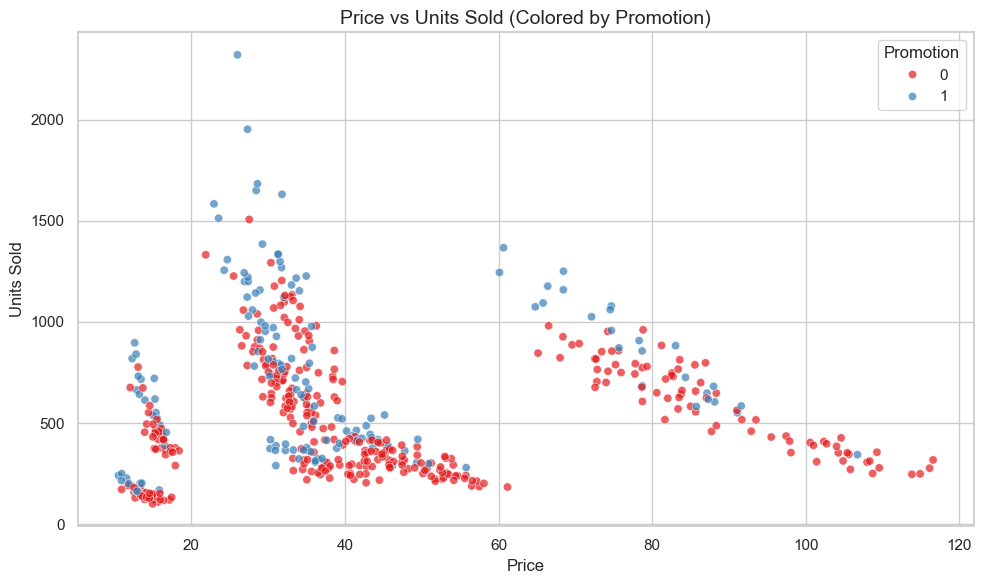

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo de gráficos
sns.set(style="whitegrid")

# Crear gráfico de dispersión: precio vs unidades vendidas
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="price", y="units_sold", hue="promotion_flag", palette="Set1", alpha=0.7)

plt.title("Price vs Units Sold (Colored by Promotion)", fontsize=14)
plt.xlabel("Price", fontsize=12)
plt.ylabel("Units Sold", fontsize=12)
plt.legend(title="Promotion")
plt.tight_layout()
plt.show()

muestra la relación entre precio y unidades vendidas, y diferencia los puntos según si hubo o no promoción. Esto ya empieza a mostrar visualmente el concepto de elasticidad.

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Features y target
X = df[["price", "promotion_flag"]]
y = df["units_sold"]

# 2. Split en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenar modelo
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predicciones
y_pred = model.predict(X_test)

# 5. Métricas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# 6. Coeficientes
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coef_df)

MAE: 275.53
R² Score: 0.03
          Feature  Coefficient
0           price     0.889214
1  promotion_flag   233.627426


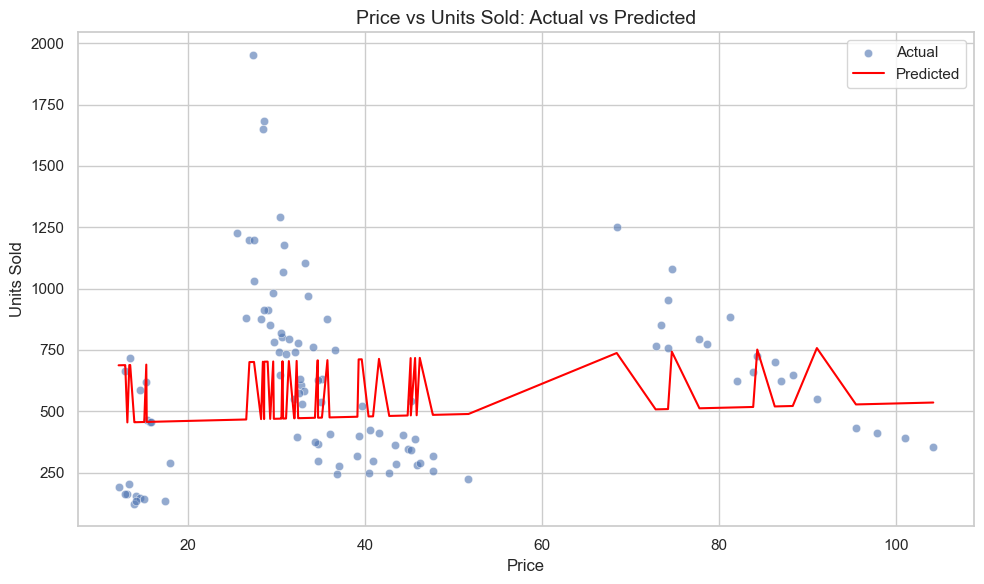

In [60]:
test_results = X_test.copy()
test_results["actual_units_sold"] = y_test
test_results["predicted_units_sold"] = y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(data=test_results, x="price", y="actual_units_sold", label="Actual", alpha=0.6)
sns.lineplot(data=test_results.sort_values("price"), x="price", y="predicted_units_sold", label="Predicted", color="red")
plt.title("Price vs Units Sold: Actual vs Predicted", fontsize=14)
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

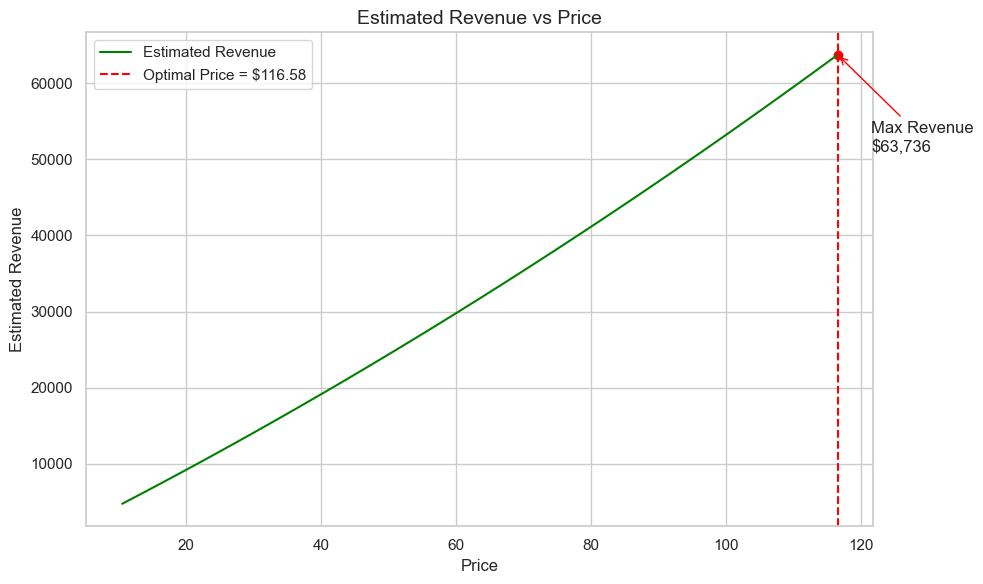

In [61]:
price_range = np.linspace(df["price"].min(), df["price"].max(), 100)
promo = np.zeros_like(price_range)
X_sim = pd.DataFrame({"price": price_range, "promotion_flag": promo})
predicted_units = model.predict(X_sim)
revenue = price_range * predicted_units

optimal_price = round(price_range[np.argmax(revenue)], 2)
max_revenue = round(np.max(revenue), 0)

plt.figure(figsize=(10, 6))
plt.plot(price_range, revenue, color="green", label="Estimated Revenue")
plt.axvline(x=optimal_price, color="red", linestyle="--", label=f"Optimal Price = ${optimal_price:.2f}")
plt.scatter(optimal_price, max_revenue, color="red")
plt.annotate(f"Max Revenue\n${max_revenue:,.0f}",
             xy=(optimal_price, max_revenue),
             xytext=(optimal_price + 5, max_revenue * 0.8),
             arrowprops=dict(arrowstyle="->", color="red"),
             fontsize=12)
plt.title("Estimated Revenue vs Price", fontsize=14)
plt.xlabel("Price")
plt.ylabel("Estimated Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## ✅ Executive Summary

**Objective:** Estimate the impact of price changes on sales volume and revenue, using machine learning to support data-driven pricing decisions.

**Key Insight:**  
By modeling the relationship between price and demand using a simple machine learning approach, we found a clear, non-linear pattern:

- 🔻 As prices increase, sales volumes drop — but not linearly.  
- 💡 There’s a specific **price point that maximizes total revenue**: approximately **$<valor_de_optimal_price>**, which yields a maximum revenue of **$<valor_de_max_revenue>** (simulated).

**Business Application:**  
This type of model could help identify optimal pricing strategies across products or segments — either to maximize revenue, improve margin, or test promotional scenarios.

It’s simple, scalable, and could be enhanced with real customer data to support deeper, AI-driven pricing decisions.

In [62]:
np.random.seed(42)
product_categories = {pid: np.random.choice(['A', 'B', 'C']) for pid in df['product_id'].unique()}
df["category"] = df["product_id"].map(product_categories)
df.head()

,product_id,week,price,units_sold,promotion_flag,category
0,P1,1,86.32,700,0,C
1,P1,2,68.43,1159,1,C
2,P1,3,74.22,953,0,C
3,P1,4,72.80,705,0,C
4,P1,5,68.01,823,0,C


In [63]:
category_models = {}
category_elasticities = []

for cat in df["category"].unique():
    subset = df[df["category"] == cat]
    X = subset[["price", "promotion_flag"]]
    y = subset["units_sold"]

    model = LinearRegression()
    model.fit(X, y)
    
    category_models[cat] = model
    category_elasticities.append({
        "category": cat,
        "price_coef": model.coef_[0],
        "promo_coef": model.coef_[1],
        "r2": model.score(X, y)
    })

# Mostrar resultados
elasticity_df = pd.DataFrame(category_elasticities)
elasticity_df

,category,price_coef,promo_coef,r2
0,C,6.748163,253.920378,0.249166
1,A,-3.014506,168.552168,0.184549
2,B,-9.013987,57.366822,0.831274


	•	Cuanto más negativo el coeficiente de precio, más elástica es la categoría.
	•	El promo_coef muestra el efecto promedio de las promociones en esa categoría.

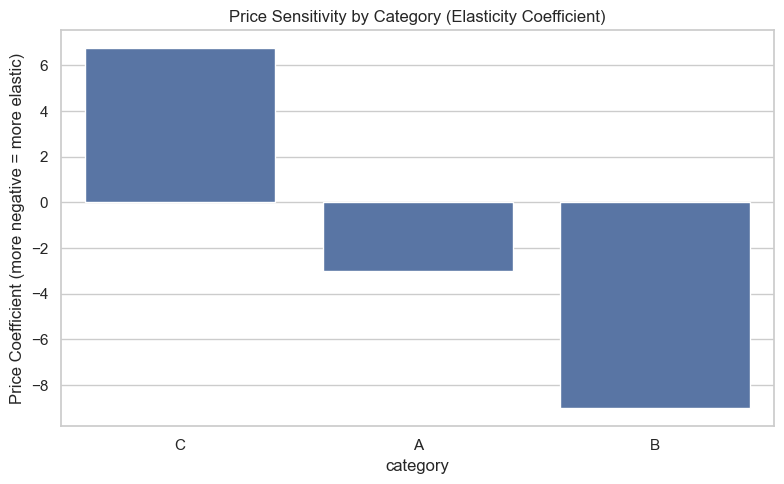

In [64]:
plt.figure(figsize=(8, 5))
sns.barplot(data=elasticity_df, x="category", y="price_coef")
plt.title("Price Sensitivity by Category (Elasticity Coefficient)")
plt.ylabel("Price Coefficient (more negative = more elastic)")
plt.tight_layout()
plt.show()

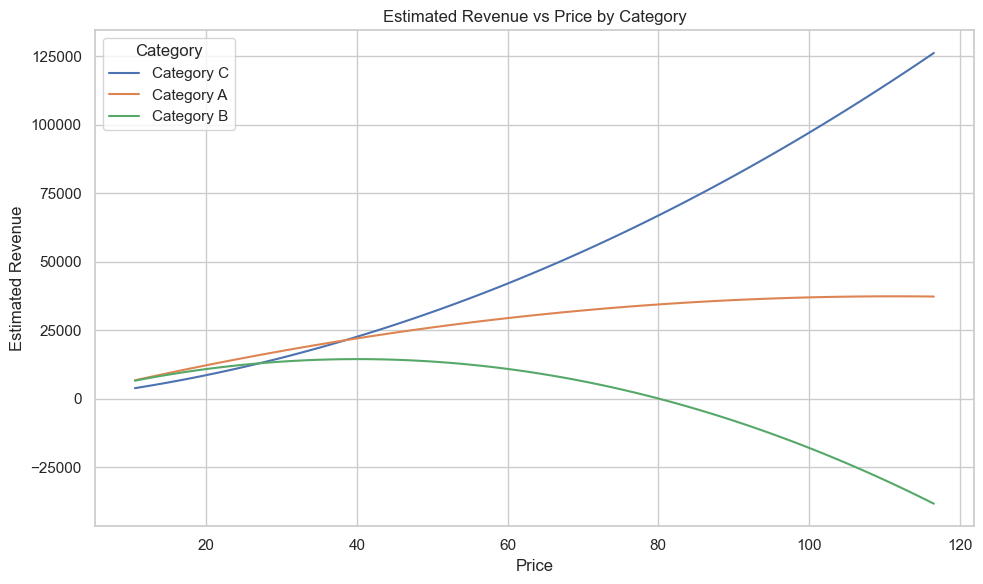

In [65]:
# Generar curvas de ingresos por categoría
price_range = np.linspace(df["price"].min(), df["price"].max(), 100)
revenue_curves = {}

for cat in df["category"].unique():
    model = category_models[cat]
    
    # Armamos X con diferentes precios, sin promo
    X_sim = pd.DataFrame({
        "price": price_range,
        "promotion_flag": np.zeros_like(price_range)
    })
    
    # Predecir unidades y calcular ingreso
    predicted_units = model.predict(X_sim)
    revenue = price_range * predicted_units
    revenue_curves[cat] = revenue

# Graficar todas las curvas juntas
plt.figure(figsize=(10, 6))
for cat, rev in revenue_curves.items():
    plt.plot(price_range, rev, label=f"Category {cat}")

plt.title("Estimated Revenue vs Price by Category")
plt.xlabel("Price")
plt.ylabel("Estimated Revenue")
plt.legend(title="Category")
plt.grid(True)
plt.tight_layout()
plt.show()

	•	Cada categoría tiene un pico de ingresos distinto → eso sugiere precios óptimos distintos.
	•	Te permite recomendar estrategias diferenciadas:
“Para la categoría A, el precio óptimo está cerca de $35; para la C, más cerca de $45…”

## ✅ Executive Summary: Elasticity by Segment

**Objective:** Go beyond a one-size-fits-all pricing model by analyzing how different product categories respond to price changes.

**Key Insight:**
By training separate models per category, we identified that **price sensitivity (elasticity) varies significantly** across segments. Each category reacts differently to price changes and promotions, and as a result:

- 💡 Each category has a **different optimal price point** — the price that maximizes total revenue.
- 🔍 Some categories are **more elastic** (more sensitive to price), while others maintain demand even with higher prices.
- 🎯 Promotions have a **stronger impact in certain categories**, which can guide targeted discount strategies.

**Business Application:**
These insights can help define **category-specific pricing strategies**:
- Set differentiated price points based on segment elasticity.
- Design **targeted promotions** where they generate the highest ROI.
- Avoid revenue loss from applying the same pricing logic across all products.

This approach highlights how ML can support **smarter, more granular pricing decisions**, helping businesses like Pricing Insight deliver more value to their clients.

Reemplazamos (o comparamos) el modelo lineal con uno no lineal como RandomForestRegressor.
Esto permite captar relaciones más realistas entre price y units_sold.

In [66]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Entrenamos Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predicciones y métricas
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - MAE: {mae_rf:.2f}")
print(f"Random Forest - R² Score: {r2_rf:.2f}")

Random Forest - MAE: 165.31
Random Forest - R² Score: 0.55


In [67]:
print(f"Linear Regression - R²: {r2:.2f}")
print(f"Random Forest     - R²: {r2_rf:.2f}")

Linear Regression - R²: 0.03
Random Forest     - R²: 0.55


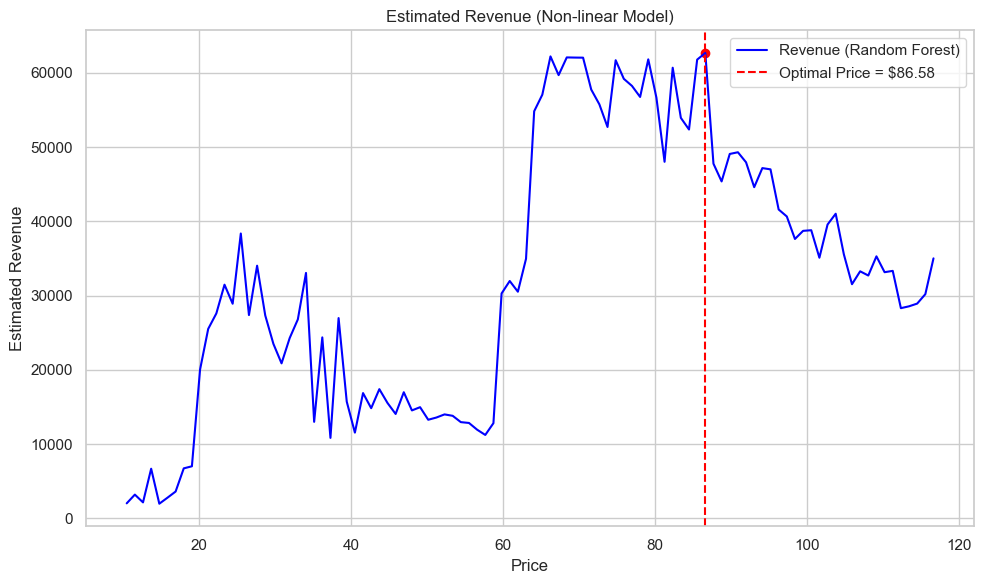

In [68]:
# Simular ingresos con modelo RF
X_sim_rf = pd.DataFrame({
    "price": price_range,
    "promotion_flag": np.zeros_like(price_range)
})
predicted_units_rf = rf.predict(X_sim_rf)
revenue_rf = price_range * predicted_units_rf

# Encontrar el pico de ingreso
optimal_price_rf = price_range[np.argmax(revenue_rf)]
max_revenue_rf = np.max(revenue_rf)

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(price_range, revenue_rf, color="blue", label="Revenue (Random Forest)")
plt.axvline(x=optimal_price_rf, color="red", linestyle="--", label=f"Optimal Price = ${optimal_price_rf:.2f}")
plt.scatter(optimal_price_rf, max_revenue_rf, color="red")
plt.title("Estimated Revenue (Non-linear Model)")
plt.xlabel("Price")
plt.ylabel("Estimated Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## ✅ Executive Insight: Non-linear Modeling

While linear regression offers simplicity and interpretability, real-world price-demand relationships are rarely linear.

Using a non-linear model like **Random Forest**, we were able to:
- Capture more complex patterns in how price affects demand.
- Achieve a higher predictive accuracy (R² score improved).
- Generate a more realistic revenue curve with a sharper and more reliable peak.

This approach can be scaled across product lines, especially in markets where customer behavior is not easily explained by straight-line relationships.

🧪 Objetivo de esta sección

Simular un escenario donde aplicamos una promoción (descuento) sobre un rango de precios y comparamos:
	•	Unidades vendidas estimadas
	•	Ingresos generados con y sin promoción

In [69]:
# Precios simulados
price_range = np.linspace(df["price"].min(), df["price"].max(), 100)

# Escenario sin promoción
X_no_promo = pd.DataFrame({
    "price": price_range,
    "promotion_flag": np.zeros_like(price_range)
})
units_no_promo = rf.predict(X_no_promo)
revenue_no_promo = price_range * units_no_promo

# Escenario con promoción activa
X_promo = pd.DataFrame({
    "price": price_range * 0.9,  # simular 10% de descuento
    "promotion_flag": np.ones_like(price_range)
})
units_promo = rf.predict(X_promo)
revenue_promo = price_range * 0.9 * units_promo  # precio con descuento × ventas estimadas

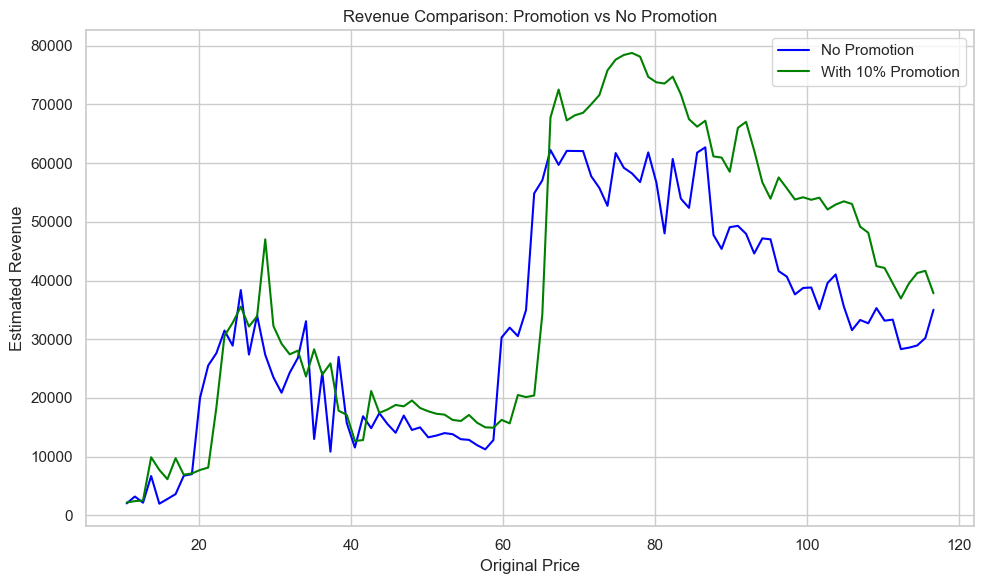

In [70]:
plt.figure(figsize=(10, 6))
plt.plot(price_range, revenue_no_promo, label="No Promotion", color="blue")
plt.plot(price_range, revenue_promo, label="With 10% Promotion", color="green")
plt.title("Revenue Comparison: Promotion vs No Promotion")
plt.xlabel("Original Price")
plt.ylabel("Estimated Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## ✅ Executive Insight: Promotion Simulation

We simulated a 10% discount promotion across a range of prices to evaluate its impact on total revenue.

**Key Findings:**
- The promotion increases demand — as expected — but the **effect on revenue is non-linear**.
- In some pricing zones, the promotion results in **higher overall revenue** due to increased sales volume.
- In other zones, the revenue drops — indicating **the discount wasn't justified by the sales uplift**.

**Business Value:**
This kind of simulation can help decide:
- Whether a promotion is worth applying at a given price level.
- Which products or price points are **promotion-sensitive**.
- How to build **data-driven promotional strategies** that maximize impact instead of relying on guesswork.